In [1]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Input, Dense, Conv2D, Flatten, MaxPooling2D, Dropout)
from tensorflow.keras.utils import to_categorical # for encoding

# Cifar_10 dataset

In [2]:
from tensorflow.keras.datasets import cifar10

In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [4]:
# data preprocessing
X_train.shape #since cifar_10 already has channel as 3 no reshape needed

(50000, 32, 32, 3)

In [5]:
X_test.shape

(10000, 32, 32, 3)

In [6]:
y_train.shape

(50000, 1)

In [7]:
y_test.shape

(10000, 1)

In [8]:
# normalization
X_train = X_train / 255
X_test = X_test / 255

In [9]:
# encoding
y_train =  to_categorical(y_train,10)
y_test =  to_categorical(y_test,10)

# Model 

In [10]:
input_shape = X_train.shape[1:]
num_classes = y_train.shape[1]

In [33]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, (3,3), padding="same", activation="relu"))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), padding="same", activation="relu"))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), padding="same", activation="relu"))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(120,activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(100,activation="relu"))
model.add(Dropout(0.3))
# output
model.add(Dense(num_classes,activation="softmax"))
model.compile(optimizer="adam",loss="categorical_crossentropy", metrics=["accuracy"])

In [34]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 120)            │       245,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        12,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,238 (1.34 MB)

 Trainable params: 352,238 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# stooping validation early
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [36]:
history = model.fit(
    X_train, y_train, epochs = 30, batch_size = 64, validation_split =0.2,verbose = 1, callbacks=[early_stop],
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.3569 - loss: 1.7275 - val_accuracy: 0.5061 - val_loss: 1.3515
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5247 - loss: 1.3141 - val_accuracy: 0.5921 - val_loss: 1.1226
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.6066 - loss: 1.1116 - val_accuracy: 0.6587 - val_loss: 0.9875
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.6568 - loss: 0.9799 - val_accuracy: 0.6511 - val_loss: 1.0091
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.6977 - loss: 0.8756 - val_accuracy: 0.6974 - val_loss: 0.8682
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7217 - loss: 0.8031 - val_accuracy: 0.7163 - val_loss: 0.8200
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7464 - loss: 0.7309 - val_accuracy: 0.7224 - val_loss: 0.7877
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.7612 - loss: 0.6886 - 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame(history.history)
df[["loss","val_loss"]].plot(kind = "line")

NameError: name 'history' is not defined

The graph shows the training and validation loss of the CNN across different epochs. Initially, both losses decrease, indicating that the model is learning and generalizing well. The training loss continues to decrease throughout training. However, after approximately epoch 8, the validation loss begins to increase while the training loss continues to decrease. This indicates the beginning of overfitting, where the model continues improving on the training data but no longer improves on unseen validation data. Therefore, the model performs best around epoch 8 based on the validation loss.

In [38]:
import numpy as np
y_predict = np.argmax(model.predict(X_test),axis =1)
y_predict

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


array([3, 1, 8, ..., 5, 4, 7], shape=(10000,))

In [40]:
y_true = np.argmax(y_test, axis = 1)
y_true

array([3, 8, 8, ..., 5, 1, 7], shape=(10000,))

In [41]:
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import seaborn as sns

<Axes: >

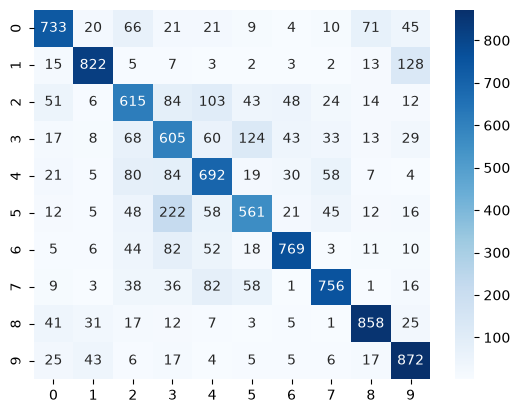

In [42]:
sns.heatmap(
    confusion_matrix(y_true, y_predict),
    annot= True,
    fmt=".0f",
    cmap="Blues"
    )

The confusion matrix shows the performance of the CNN model across the 10 CIFAR-10 classes. The diagonal values represent correctly classified images, while the off-diagonal values represent misclassifications. The model performs particularly well on classes such as trucks, ships, and automobiles. However, some classes are more difficult to distinguish, especially cats and dogs, where a noticeable number of dog images are classified as cats. Overall, the strong diagonal values indicate that the model is correctly classifying a large proportion of the test images, while the off-diagonal values help identify the specific classes where the model still makes errors.

In [43]:
recall = recall_score(y_true,y_predict, average="weighted")
recall

0.7283

In [44]:
precision =  precision_score(y_true, y_predict, average="weighted")
precision

0.7332289912035194

In [45]:
f1 = f1_score(y_true, y_predict, average="weighted")
f1

0.7290770950084883

In [46]:
from sklearn.metrics import classification_report

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print(classification_report(
    y_true,
    y_predict,
    target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.79      0.73      0.76      1000
  automobile       0.87      0.82      0.84      1000
        bird       0.62      0.61      0.62      1000
         cat       0.52      0.60      0.56      1000
        deer       0.64      0.69      0.66      1000
         dog       0.67      0.56      0.61      1000
        frog       0.83      0.77      0.80      1000
       horse       0.81      0.76      0.78      1000
        ship       0.84      0.86      0.85      1000
       truck       0.75      0.87      0.81      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000



In [50]:
# saving
model.save("cifar10_cnn.keras")